# Feature Parity Validation

Verifies that features computed on a **rolling sliding window** (replicating live-trading) are **numerically identical** to the same features computed in a single **bulk pass** over the full dataset.

Uses `add_feature_library()` directly — no model pack or scaler required.  
Any feature that diverges between paths is a candidate for removal from `add_feature_library` before training.

## Methodology

| Path | Description |
|---|---|
| **Bulk** | Load the full OHLCV file → run `add_feature_library` once → extract rows at test-bar timestamps |
| **Sliding window** | For each test bar `i`, extract the last `MAXLEN` rows of `df_full` up to `i` → run `add_feature_library` → `dropna` → take the **last row** |

The final row of the sliding-window run should match the corresponding row in the bulk matrix exactly if the feature computations are stable.  Any discrepancy reveals a drift source (e.g. long-lookback indicators not yet stabilised at smaller window sizes).

## Steps
1. **Configuration** — choose dataset, window size, number of test bars
2. **Load OHLCV** — read the raw CSV
3. **Bulk features** — compute `add_feature_library` on the full dataset
4. **Sliding-window features** — replicate live window logic
5. **Alignment & diff** — inner-join on timestamp, compute `|bulk − sliding|`
6. **Summary statistics** — per-feature mean/max/p95 absolute difference
7. **Visualisations** — heatmap, worst-feature bar chart, time-series overlays
8. **MAXLEN sensitivity** — show how drift reduces as window size grows
9. **Pruning export** — print drifting / clean feature lists for `add_feature_library` review


In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

# ── Ensure ModelWorkbench/Learn is importable ─────────────────────────────────
_wb = os.path.abspath(os.getcwd())
for _p in [_wb, os.path.join(_wb, 'Learn')]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from Learn.features import add_feature_library

# ── Configuration ─────────────────────────────────────────────────────────────
# Raw OHLCV CSV to validate
DS_NAME              = '../data/US500_M1_520weeks.csv'

# Limit rows loaded (None = full file; int = tail N rows for speed)
N_ROWS               = 200_000

# Sliding-window size — must match the live deque maxlen in your strategy
MAXLEN               = 7_000

# Number of test bars to sample from the second half of the dataset
N_TEST_BARS          = 100

# Feature library flags — must match the values used during training
INCLUDE_MTF          = True
FAST_MODE            = False

# Drift alert threshold — features with mean |diff| above this are flagged
DIFF_ALERT_THRESHOLD = 1e-4

# Regime params — set to None to skip computing fl_regime
regime_params = {
    "ma_period"          : 30,
    "slope_smoothness"   : 50,
    "regime_min_duration": 0,
    "atr_window"         : 60,
    "atr_lookback"       : 1440,
    "atr_percentile"     : 0.0,
    "slope_threshold"    : 5e-6,
}

print(f"Data       : {DS_NAME}")
print(f"N_ROWS     : {N_ROWS}")
print(f"MAXLEN     : {MAXLEN}")
print(f"N_TEST_BARS: {N_TEST_BARS}")
print(f"INCLUDE_MTF: {INCLUDE_MTF}")
print(f"FAST_MODE  : {FAST_MODE}")


Data       : ../data/US500_M1_520weeks.csv
N_ROWS     : 200000
MAXLEN     : 7000
N_TEST_BARS: 100
INCLUDE_MTF: True
FAST_MODE  : False


## Load & prepare full OHLCV dataset

In [2]:
df_full = pd.read_csv(DS_NAME)
if N_ROWS is not None:
    df_full = df_full.tail(N_ROWS)
df_full = df_full.sort_values('Time').reset_index(drop=True)
df_full['Time'] = pd.to_datetime(df_full['Time'])

print(f"Full dataset : {len(df_full):,} rows  {df_full['Time'].iloc[0]} → {df_full['Time'].iloc[-1]}")
print(f"Columns      : {list(df_full.columns)}")

assert len(df_full) > MAXLEN * 2, (
    f"Dataset ({len(df_full):,} rows) is too small for MAXLEN={MAXLEN}. "
    "Reduce MAXLEN or increase N_ROWS."
)

# Test bars are sampled evenly from the second half (ensures warmup is complete)
half  = len(df_full) // 2
min_i = max(half, MAXLEN)
max_i = len(df_full) - 1
assert min_i <= max_i, "Dataset too small — cannot sample test bars."

test_indices = np.linspace(min_i, max_i, N_TEST_BARS, dtype=int)
test_times   = df_full['Time'].iloc[test_indices].values
print(f"\nTest bar range : index {test_indices[0]} → {test_indices[-1]}")
print(f"               : {test_times[0]} → {test_times[-1]}")


Full dataset : 200,000 rows  2025-11-24 10:46:00+00:00 → 2026-06-19 16:59:00+00:00
Columns      : ['Time', 'Open', 'High', 'Low', 'Close', 'Volume']

Test bar range : index 100000 → 199999
               : 2026-03-10T14:14:00.000000 → 2026-06-19T16:59:00.000000


## Bulk processing path
Compute `add_feature_library` on the **full dataset** in one pass (as done during training), then extract the rows corresponding to the test bar timestamps.


In [3]:
_feat_kwargs = dict(include_mtf=INCLUDE_MTF, fast_mode=FAST_MODE, regime_params=regime_params)

print("Running add_feature_library on full dataset …")
_t0 = time.time()
df_bulk_feat  = add_feature_library(df_full.copy(), **_feat_kwargs)
df_bulk_clean = df_bulk_feat.dropna(how='any').reset_index(drop=True)
print(f"  Done in {time.time()-_t0:.1f}s")

print(f"  df_full rows      : {len(df_full):,}")
print(f"  after features    : {len(df_bulk_feat):,}")
print(f"  after dropna      : {len(df_bulk_clean):,}")
print(f"  total columns     : {len(df_bulk_feat.columns)}")

# Identify raw feature columns (exclude OHLCV / metadata columns)
_OHLCV_COLS = {'Time', 'Open', 'High', 'Low', 'Close', 'Volume', 'target', 'sell_y', 'buy_y'}
feat_cols = [c for c in df_bulk_clean.columns if c not in _OHLCV_COLS]

print(f"  feature columns   : {len(feat_cols)}")
print(f"  First 5: {feat_cols[:5]}")
print(f"  Last  5: {feat_cols[-5:]}")

# Build a lookup: timestamp → row index in df_bulk_clean
bulk_time_to_idx = {t: i for i, t in enumerate(df_bulk_clean['Time'].values)}


Running add_feature_library on full dataset …
  Done in 36.1s
  df_full rows      : 200,000
  after features    : 200,000
  after dropna      : 199,179
  total columns     : 203
  feature columns   : 197
  First 5: ['fl_log_return', 'fl_hl_range', 'fl_body', 'fl_upper_wick', 'fl_lower_wick']
  Last  5: ['MTF_30min_hh', 'MTF_30min_ll', 'MTF_30min_donchian_trend', 'MTF_30min_time_in_trend', 'fl_regime']


## Sliding-window processing path
For each test bar `i`, extract `df_full[i - MAXLEN + 1 : i + 1]` → run `add_feature_library` → `dropna` → take **only the last row**.  
This replicates exactly what the live strategy sees on every bar.


In [4]:
sliding_rows    = []   # last raw feature row per test bar
sliding_times   = []   # timestamp of that bar
sliding_skipped = []   # bars skipped due to data shortfall or missing columns

for bar_idx in tqdm(test_indices, desc='Sliding-window'):
    start    = max(0, bar_idx - MAXLEN + 1)
    df_win   = df_full.iloc[start : bar_idx + 1].copy().reset_index(drop=True)
    bar_time = df_full['Time'].iloc[bar_idx]

    df_win_feat  = add_feature_library(df_win, **_feat_kwargs)
    df_win_clean = df_win_feat.dropna(how='any').reset_index(drop=True)

    if len(df_win_clean) < 50:
        sliding_skipped.append(bar_idx)
        continue

    # Ensure all expected feature columns are present
    _avail = [c for c in feat_cols if c in df_win_clean.columns]
    if len(_avail) != len(feat_cols):
        sliding_skipped.append(bar_idx)
        continue

    sliding_rows.append(df_win_clean.iloc[-1][feat_cols].to_numpy(dtype=np.float64))
    sliding_times.append(bar_time)

sliding_df = pd.DataFrame(sliding_rows, columns=feat_cols)
sliding_df.insert(0, 'bar_time', sliding_times)

print(f"Test bars processed : {len(sliding_times)}")
print(f"Skipped (data short): {len(sliding_skipped)}")
print(f"sliding_df shape    : {sliding_df.shape}")


Sliding-window:   0%|          | 0/100 [00:00<?, ?it/s]

Test bars processed : 100
Skipped (data short): 0
sliding_df shape    : (100, 198)


## Alignment — join bulk and sliding on timestamp

In [5]:
# Pull the matching bulk rows by timestamp
bulk_matched_rows    = []
sliding_matched_rows = []
matched_times        = []

for idx, row in sliding_df.iterrows():
    t = row['bar_time']
    bulk_i = bulk_time_to_idx.get(np.datetime64(t))
    if bulk_i is None:
        # Timestamp dropped by bulk dropna — skip
        continue
    bulk_matched_rows.append(
        df_bulk_clean.iloc[bulk_i][feat_cols].to_numpy(dtype=np.float64)
    )
    sliding_matched_rows.append(row[feat_cols].to_numpy(dtype=np.float64))
    matched_times.append(t)

if len(matched_times) == 0:
    bulk_mat    = np.empty((0, len(feat_cols)), dtype=np.float64)
    sliding_mat = np.empty((0, len(feat_cols)), dtype=np.float64)
    diff_mat    = np.empty((0, len(feat_cols)), dtype=np.float64)
    diff_df     = pd.DataFrame(columns=['bar_time', *feat_cols])

    print("Matched bars : 0")
    print(f"Feature dims : {len(feat_cols)}")
    print("\nNo matched timestamps between bulk and sliding paths.")
    print(f"diff_df shape : {diff_df.shape}")
else:
    bulk_mat    = np.vstack(bulk_matched_rows).astype(np.float64)   # (M, F)
    sliding_mat = np.vstack(sliding_matched_rows).astype(np.float64) # (M, F)

    # Safety: align widths if needed
    n_feat = min(bulk_mat.shape[1], sliding_mat.shape[1], len(feat_cols))
    if n_feat != len(feat_cols):
        feat_cols = feat_cols[:n_feat]
    bulk_mat    = bulk_mat[:, :n_feat]
    sliding_mat = sliding_mat[:, :n_feat]

    print(f"Matched bars : {len(matched_times)}")
    print(f"Feature dims : {bulk_mat.shape[1]}")

    # Absolute difference matrix
    diff_mat = np.abs(bulk_mat - sliding_mat)   # (M, F)

    diff_df = pd.DataFrame(diff_mat, columns=feat_cols)
    diff_df.insert(0, 'bar_time', matched_times)

    print(f"\ndiff_df shape     : {diff_df.shape}")
    print(f"Global max |diff| : {diff_mat.max():.8f}")
    print(f"Global mean |diff|: {diff_mat.mean():.8f}")


Matched bars : 100
Feature dims : 197

diff_df shape     : (100, 198)
Global max |diff| : 0.00001010
Global mean |diff|: 0.00000001


## Summary statistics — per-feature divergence

In [6]:
DIFF_ALERT_THRESHOLD = 1e-4   # flag features where mean |diff| exceeds this

stats = pd.DataFrame({
    'mean_abs_diff' : diff_mat.mean(axis=0),
    'max_abs_diff'  : diff_mat.max(axis=0),
    'p95_abs_diff'  : np.percentile(diff_mat, 95, axis=0),
    'p99_abs_diff'  : np.percentile(diff_mat, 99, axis=0),
    'pct_nonzero'   : (diff_mat > 0).mean(axis=0) * 100,
    'pct_above_thr' : (diff_mat > DIFF_ALERT_THRESHOLD).mean(axis=0) * 100,
}, index=feat_cols).sort_values('mean_abs_diff', ascending=False)

n_perfect   = (stats['mean_abs_diff'] == 0).sum()
n_tiny      = ((stats['mean_abs_diff'] > 0) & (stats['mean_abs_diff'] <= DIFF_ALERT_THRESHOLD)).sum()
n_alert     = (stats['mean_abs_diff'] > DIFF_ALERT_THRESHOLD).sum()

print(f"═══════════════════════════════════════════════════════")
print(f"  Features with ZERO drift          : {n_perfect:>4}")
print(f"  Features with tiny drift (<{DIFF_ALERT_THRESHOLD:.0e}) : {n_tiny:>4}")
print(f"  Features with ALERT drift (>{DIFF_ALERT_THRESHOLD:.0e}): {n_alert:>4}")
print(f"═══════════════════════════════════════════════════════")

if n_alert == 0:
    print("\n✅  All features within tolerance — pipelines are in parity.")
else:
    print(f"\n⚠️  {n_alert} feature(s) exceed the drift threshold — review below.\n")

# Display top-40 worst features (or all if fewer)
top_n = min(40, len(stats))
display(
    stats.head(top_n).style
    .background_gradient(subset=['mean_abs_diff', 'max_abs_diff'], cmap='YlOrRd')
    .format({
        'mean_abs_diff' : '{:.6f}',
        'max_abs_diff'  : '{:.6f}',
        'p95_abs_diff'  : '{:.6f}',
        'p99_abs_diff'  : '{:.6f}',
        'pct_nonzero'   : '{:.1f}%',
        'pct_above_thr' : '{:.1f}%',
    })
)

═══════════════════════════════════════════════════════
  Features with ZERO drift          :  152
  Features with tiny drift (<1e-04) :   45
  Features with ALERT drift (>1e-04):    0
═══════════════════════════════════════════════════════

✅  All features within tolerance — pipelines are in parity.


,mean_abs_diff,max_abs_diff,p95_abs_diff,p99_abs_diff,pct_nonzero,pct_above_thr
fl_bb_pos_20,0.000001,0.000010,0.000004,0.000010,100.0%,0.0%
fl_nvi_z,0.000001,0.000006,0.000004,0.000005,100.0%,0.0%
MTF_30min_adx,0.000000,0.000001,0.000000,0.000001,100.0%,0.0%
fl_z_20,0.000000,0.000000,0.000000,0.000000,100.0%,0.0%
fl_z_60,0.000000,0.000000,0.000000,0.000000,100.0%,0.0%
MTF_30min_ema_dist,0.000000,0.000000,0.000000,0.000000,100.0%,0.0%
fl_z_128,0.000000,0.000000,0.000000,0.000000,100.0%,0.0%
MTF_30min_rsi,0.000000,0.000000,0.000000,0.000000,100.0%,0.0%
fl_bb_width_20,0.000000,0.000000,0.000000,0.000000,100.0%,0.0%
fl_z_256,0.000000,0.000000,0.000000,0.000000,100.0%,0.0%


## Visualisations

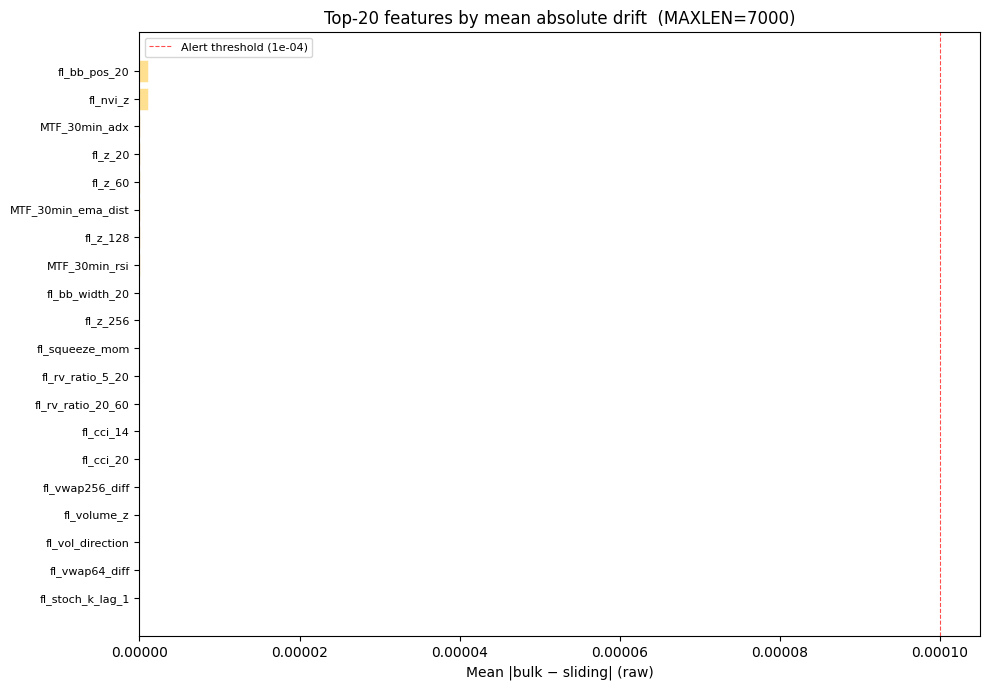

In [7]:
# ── 1. Horizontal bar chart — top-20 worst features ─────────────────────────
TOP_N_BAR = min(20, len(stats))
top_features = stats.head(TOP_N_BAR).index.tolist()

fig, ax = plt.subplots(figsize=(10, max(4, TOP_N_BAR * 0.35)))
colors = ['#d73027' if v > DIFF_ALERT_THRESHOLD else '#fee090' if v > 0 else '#91bfdb'
          for v in stats.head(TOP_N_BAR)['mean_abs_diff']]
ax.barh(
    range(TOP_N_BAR),
    stats.head(TOP_N_BAR)['mean_abs_diff'],
    color=colors,
    edgecolor='white',
    linewidth=0.4,
)
ax.set_yticks(range(TOP_N_BAR))
ax.set_yticklabels(top_features, fontsize=8)
ax.invert_yaxis()
ax.axvline(DIFF_ALERT_THRESHOLD, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label=f'Alert threshold ({DIFF_ALERT_THRESHOLD:.0e})')
ax.set_xlabel('Mean |bulk − sliding| (raw)')
ax.set_title(f'Top-{TOP_N_BAR} features by mean absolute drift  (MAXLEN={MAXLEN})')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


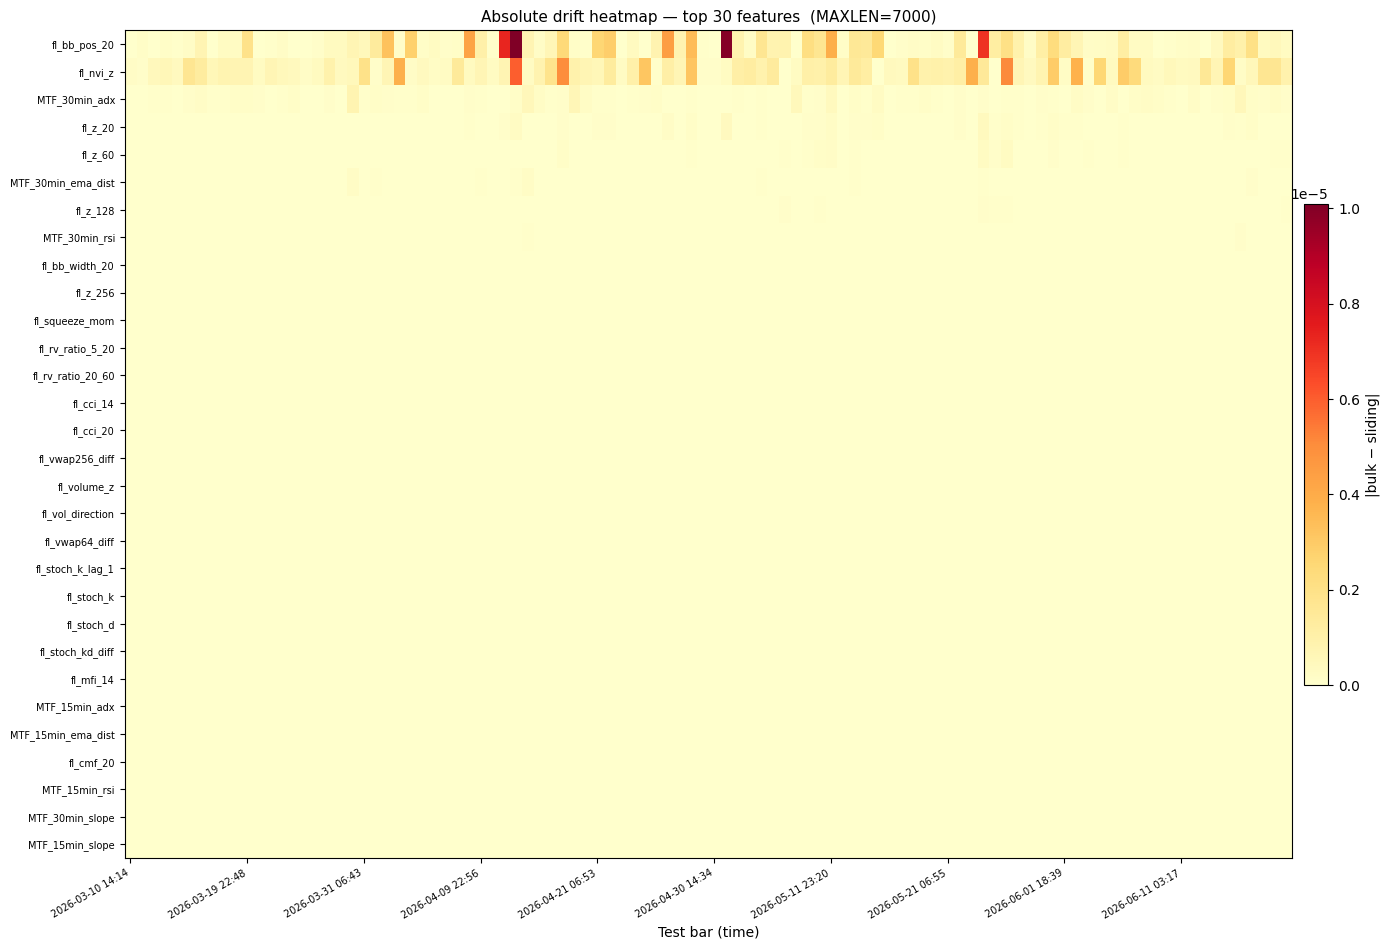

In [8]:
# ── 2. Heatmap — features × test bars ───────────────────────────────────────
# Show top-30 features on y-axis so it stays readable
HMAP_FEATS = min(30, len(stats))
hmap_cols   = stats.head(HMAP_FEATS).index.tolist()
hmap_data   = diff_df.set_index('bar_time')[hmap_cols].T  # (features, bars)

fig, ax = plt.subplots(figsize=(14, max(5, HMAP_FEATS * 0.32)))
im = ax.imshow(hmap_data.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_yticks(range(HMAP_FEATS))
ax.set_yticklabels(hmap_cols, fontsize=7)
ax.set_xticks(range(0, len(matched_times), max(1, len(matched_times) // 10)))
ax.set_xticklabels(
    [str(matched_times[i])[:16] for i in range(0, len(matched_times), max(1, len(matched_times) // 10))],
    rotation=30, ha='right', fontsize=7
)
ax.set_xlabel('Test bar (time)')
ax.set_title(f'Absolute drift heatmap — top {HMAP_FEATS} features  (MAXLEN={MAXLEN})', fontsize=11)
plt.colorbar(im, ax=ax, label='|bulk − sliding|', fraction=0.02, pad=0.01)
plt.tight_layout()
plt.show()

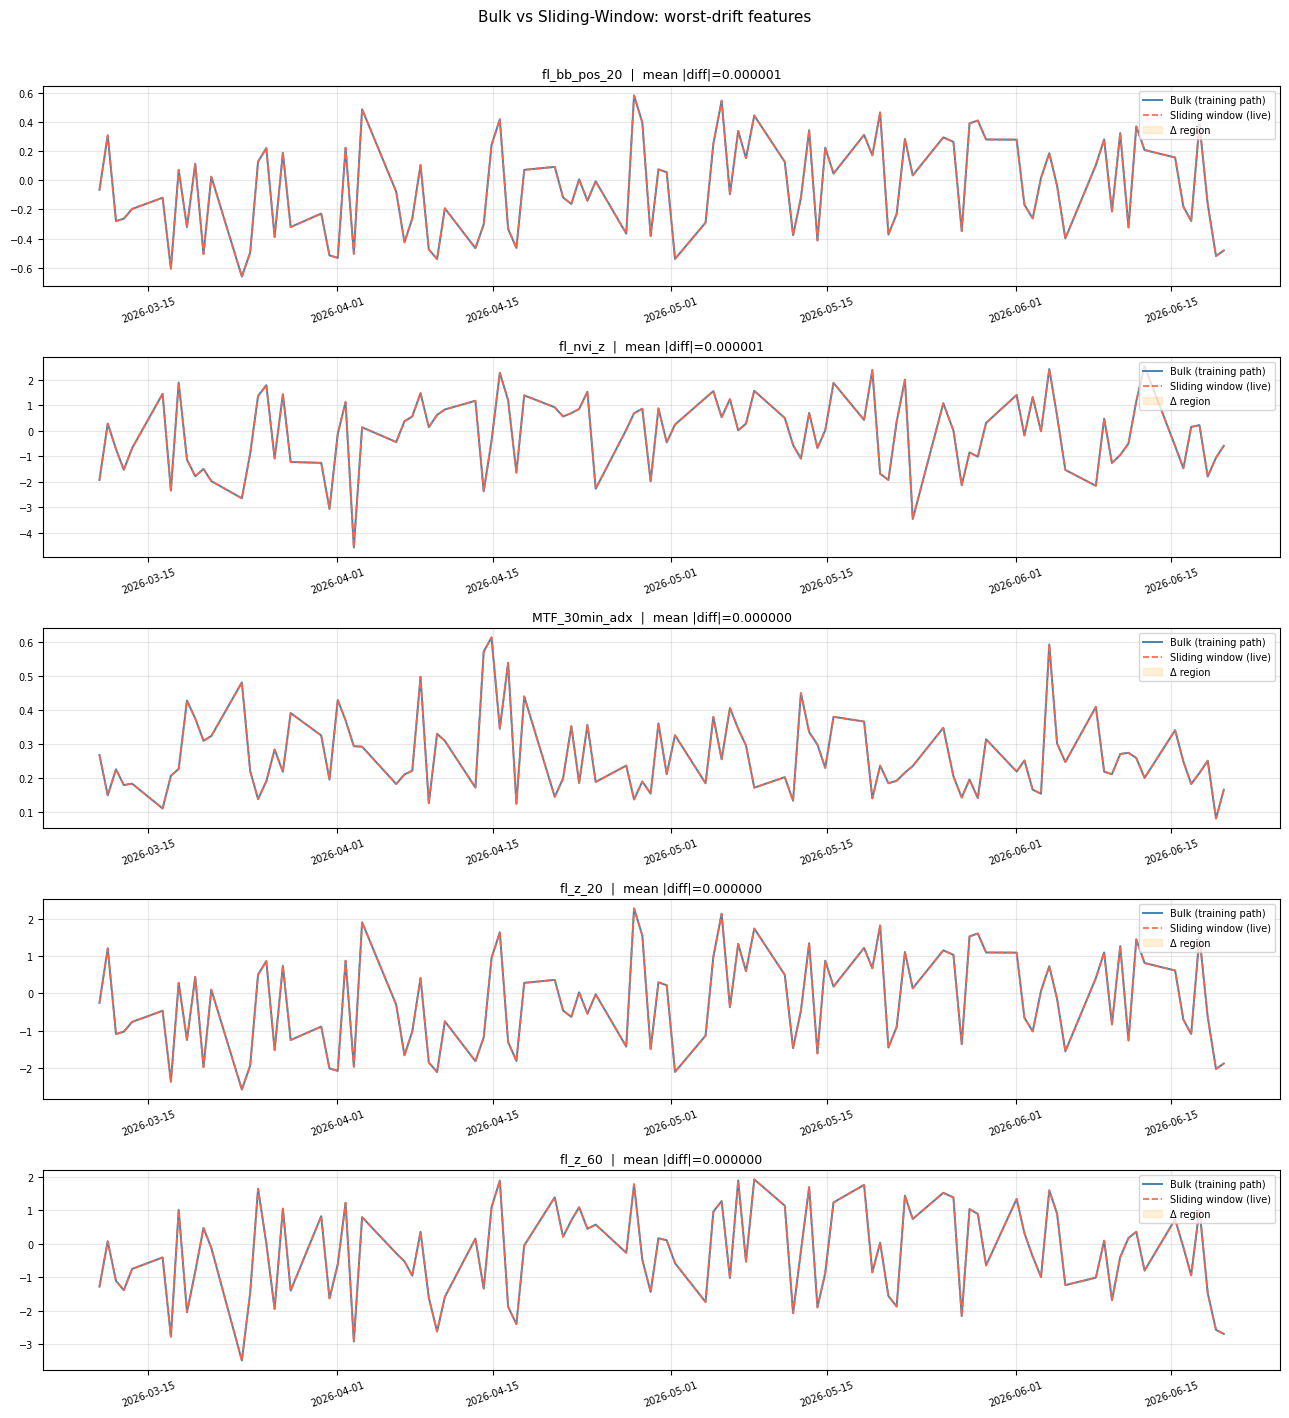

In [9]:
# ── 3. Time-series overlays — worst 5 features ──────────────────────────────
TOP_TS = min(5, len(stats))
ts_features = stats.head(TOP_TS).index.tolist()

# Rebuild bulk and sliding value series for these features
bulk_ts_df    = pd.DataFrame(bulk_mat,    columns=feat_cols)
sliding_ts_df = pd.DataFrame(sliding_mat, columns=feat_cols)
ts_times_dt   = pd.to_datetime(matched_times)

fig, axes = plt.subplots(TOP_TS, 1, figsize=(13, TOP_TS * 2.8), sharex=False)
if TOP_TS == 1:
    axes = [axes]

for ax, feat in zip(axes, ts_features):
    b_vals = bulk_ts_df[feat].values
    s_vals = sliding_ts_df[feat].values
    ax.plot(ts_times_dt, b_vals, label='Bulk (training path)',  color='steelblue', linewidth=1.4)
    ax.plot(ts_times_dt, s_vals, label='Sliding window (live)', color='tomato',    linewidth=1.2, linestyle='--')
    ax.fill_between(ts_times_dt, b_vals, s_vals, alpha=0.15, color='orange', label='Δ region')
    ax.set_title(f'{feat}  |  mean |diff|={stats.loc[feat, "mean_abs_diff"]:.6f}', fontsize=9)
    ax.tick_params(axis='x', labelsize=7, rotation=20)
    ax.tick_params(axis='y', labelsize=7)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Bulk vs Sliding-Window: worst-drift features', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## MAXLEN sensitivity analysis

Sweep `MAXLEN` over a range of window sizes to show how drift evolves as the live buffer grows.  
Features with long lookbacks (e.g. EMA200, VWAP256, z-score-60) should converge as MAXLEN increases.

MAXLEN sweep:   0%|          | 0/6 [00:00<?, ?it/s]

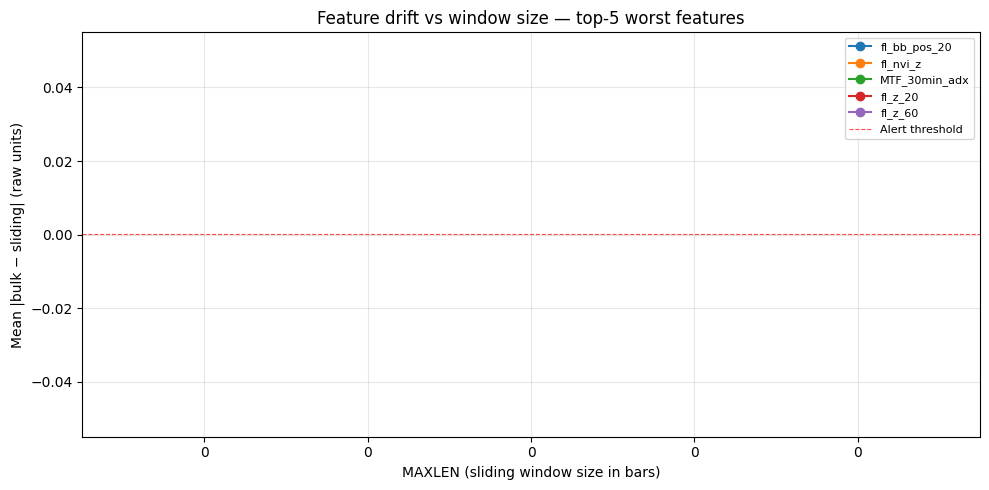

fl_bb_pos_20
fl_nvi_z
MTF_30min_adx
fl_z_20
fl_z_60


In [10]:
SWEEP_MAXLENS      = [1_000, 2_000, 3_000, 5_000, 7_000, 10_000]
SWEEP_N_TEST_BARS  = 20     # fewer bars for speed
# Only sweep bars that are valid (large enough index) for the largest window
sweep_max_win  = max(SWEEP_MAXLENS)
sweep_min_idx  = max(len(df_full) // 2, sweep_max_win)
sweep_max_idx  = len(df_full) - 1
sweep_indices  = np.linspace(sweep_min_idx, sweep_max_idx, SWEEP_N_TEST_BARS, dtype=int)

# Lookup bulk raw value for each sweep bar
sweep_bulk_rows = {}
for bar_idx in sweep_indices:
    t  = df_full['Time'].iloc[bar_idx]
    bi = bulk_time_to_idx.get(t)
    if bi is not None:
        sweep_bulk_rows[bar_idx] = (t, df_bulk_clean.iloc[bi][feat_cols].to_numpy(dtype=np.float64))

sweep_results = {}   # maxlen → mean_abs_diff per feature

for win in tqdm(SWEEP_MAXLENS, desc='MAXLEN sweep'):
    rows = []
    for bar_idx in sweep_indices:
        if bar_idx not in sweep_bulk_rows:
            continue
        bar_time, bulk_row = sweep_bulk_rows[bar_idx]

        start  = max(0, bar_idx - win + 1)
        df_win = df_full.iloc[start : bar_idx + 1].copy().reset_index(drop=True)
        df_wf  = add_feature_library(df_win, **_feat_kwargs)
        df_wc  = df_wf.dropna(how='any').reset_index(drop=True)

        if len(df_wc) < 50:
            continue
        _avail = [c for c in feat_cols if c in df_wc.columns]
        if len(_avail) != len(feat_cols):
            continue

        rows.append(np.abs(bulk_row - df_wc.iloc[-1][feat_cols].to_numpy(dtype=np.float64)))

    if rows:
        sweep_results[win] = np.array(rows).mean(axis=0)

# Pick the top-5 most-drifting features (from main analysis) to plot
sweep_top5      = stats.head(min(5, len(stats))).index.tolist()
sweep_feat_idxs = [feat_cols.index(f) for f in sweep_top5 if f in feat_cols]

fig, ax = plt.subplots(figsize=(10, 5))
for fi, feat in zip(sweep_feat_idxs, sweep_top5):
    ys = [sweep_results[w][fi] if w in sweep_results else np.nan for w in SWEEP_MAXLENS]
    ax.plot(SWEEP_MAXLENS, ys, marker='o', label=feat)

ax.axhline(DIFF_ALERT_THRESHOLD, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='Alert threshold')
ax.set_xlabel('MAXLEN (sliding window size in bars)')
ax.set_ylabel('Mean |bulk − sliding| (raw units)')
ax.set_title('Feature drift vs window size — top-5 worst features')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

# Print convergence table
sweep_table = pd.DataFrame(
    {w: sweep_results[w][sweep_feat_idxs] for w in SWEEP_MAXLENS if w in sweep_results},
    index=sweep_top5,
)
sweep_table.columns = [f'MAXLEN={w:,}' for w in sweep_table.columns]
display(sweep_table.style.background_gradient(cmap='YlOrRd', axis=1).format('{:.8f}'))


## Diagnosis

Use the cells below to interpret results:

| Observation | Likely cause |
|---|---|
| Drift is **zero for all features** | Pipelines are in perfect parity ✅ |
| Features like `fl_ema200_*`, `fl_vwap256_diff`, `fl_z_60` drift **and reduce as MAXLEN increases** | Long-lookback indicator not yet stabilised — increase `MAXLEN` or remove the feature from `add_feature_library` |
| Short-lookback features (e.g. `fl_rsi_14`, `fl_ema8_*`) also drift | Possible NaN-drop ordering difference or off-by-one in sliding window — compare `df_bulk_clean` vs `df_wc` row counts |
| Drift is **non-zero but constant** across all MAXLEN values | Systemic alignment issue (e.g. different sort order, deduplication behaviour, or stateful indicator) |
| Drift appears only in **binary/ternary flags** (value ≈ 1.0) | Indicator producing different discrete values at window boundaries — check the feature's lookback requirement |


## Pruning export

Print the set of features that **fail** parity (candidates for removal from `add_feature_library`) and the **clean** feature list as a copy-pasteable Python list.


In [11]:
# ── Feature parity report ─────────────────────────────────────────────────────
# Run after the Summary Statistics cell to see which features to remove.
# Change PRUNE_MAXLEN to the window size at which you want to evaluate drift
# (e.g. use the sweep results above to pick the minimum acceptable MAXLEN).
PRUNE_MAXLEN = MAXLEN

print(f"{'='*70}")
print(f"  FEATURE PARITY REPORT")
print(f"  MAXLEN={PRUNE_MAXLEN:,}  |  alert threshold={DIFF_ALERT_THRESHOLD:.0e}")
print(f"{'='*70}")

_n_perfect = (stats['mean_abs_diff'] == 0).sum()
_n_tiny    = ((stats['mean_abs_diff'] > 0) & (stats['mean_abs_diff'] <= DIFF_ALERT_THRESHOLD)).sum()
_n_alert   = (stats['mean_abs_diff'] > DIFF_ALERT_THRESHOLD).sum()

print(f"  Total features        : {len(stats)}")
print(f"  Zero drift            : {_n_perfect}")
print(f"  Tiny drift (pass)     : {_n_tiny}")
print(f"  ALERT drift (fail)    : {_n_alert}")
print()

dirty_features = stats[stats['mean_abs_diff'] >  DIFF_ALERT_THRESHOLD].index.tolist()
clean_features = stats[stats['mean_abs_diff'] <= DIFF_ALERT_THRESHOLD].index.tolist()

# ── Features to remove ───────────────────────────────────────────────────────
if dirty_features:
    print(f"⚠  Features to REMOVE from add_feature_library ({len(dirty_features)}):")
    _dirty_stats = stats.loc[dirty_features, ['mean_abs_diff', 'max_abs_diff', 'p95_abs_diff']]
    for feat, row in _dirty_stats.iterrows():
        print(f"    {feat:<52}  mean={row['mean_abs_diff']:.6f}  max={row['max_abs_diff']:.6f}")
else:
    print("✅  No features exceed the alert threshold — library is fully stable.")

print()

# ── Clean feature list (copy-pasteable) ──────────────────────────────────────
print(f"✅  Clean features ({len(clean_features)}) — copy-pasteable list:")
print()
print("clean_features = [")
for _f in clean_features:
    print(f"    '{_f}',")
print("]")


  FEATURE PARITY REPORT
  MAXLEN=7,000  |  alert threshold=1e-04
  Total features        : 197
  Zero drift            : 152
  Tiny drift (pass)     : 45
  ALERT drift (fail)    : 0

✅  No features exceed the alert threshold — library is fully stable.

✅  Clean features (197) — copy-pasteable list:

clean_features = [
    'fl_bb_pos_20',
    'fl_nvi_z',
    'MTF_30min_adx',
    'fl_z_20',
    'fl_z_60',
    'MTF_30min_ema_dist',
    'fl_z_128',
    'MTF_30min_rsi',
    'fl_bb_width_20',
    'fl_z_256',
    'fl_squeeze_mom',
    'fl_rv_ratio_5_20',
    'fl_rv_ratio_20_60',
    'fl_cci_14',
    'fl_cci_20',
    'fl_vwap256_diff',
    'fl_volume_z',
    'fl_vol_direction',
    'fl_vwap64_diff',
    'fl_stoch_k_lag_1',
    'fl_stoch_k',
    'fl_stoch_d',
    'fl_stoch_kd_diff',
    'fl_mfi_14',
    'MTF_15min_adx',
    'MTF_15min_ema_dist',
    'fl_cmf_20',
    'MTF_15min_rsi',
    'MTF_30min_slope',
    'MTF_15min_slope',
    'fl_slope_10',
    'fl_slope_10_norm',
    'MTF_5min_slope',
  